In [1]:
import sys, torch, numpy as np
from tqdm.auto import tqdm
from torch.utils.data import DataLoader

MOCID_DIR = "/home/thor/Programming/IRSTD/methods/SOTA/MOCID"
if MOCID_DIR not in sys.path:
    sys.path.insert(0, MOCID_DIR)

from eval import (
    collate_eval,
    decode_outputs,
    predict_image,
    count_params_m,
    _strip_compile,
    iou_matrix,
)
from mocid import MOCID, MOCIDDataset, Config

MOCID_CKPTS = {
    "MOCID-FISTA": "/home/thor/Programming/IRSTD/methods/SOTA/MOCID/runs/batch_4/fista_best.pth",
    "MOCID-DAM": "/home/thor/Programming/IRSTD/methods/SOTA/MOCID/runs/batch_4/dam_best.pth",
}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
STRIDES = [8, 16, 32]
NUM_CLASSES = 1
SCORE_THR = "f1"
SCORE_FLOOR = 1e-3
NMS_IOU = 0.65
MATCH_IOU = 0.5

/home/thor/Programming/IRSTD/methods/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/thor/Programming/IRSTD/methods/env/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/thor/Programming/IRSTD/methods/VMamba/classification/models/csms6s.py:73: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd
/home/thor/Programming/IRSTD/methods/VMamba/classification/models/csms6s.py:90: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.cus

.+FISTA (no DAM) : 9.49 M   (target 9.45)
.+FISTA+DAM      : 12.52 M    (target 13.05)


In [ ]:
def _areas(b):
    """Calculate the pixel surface areas for a set of bounding boxes in (x1, y1, x2, y2) format.
    Returns a 1D NumPy array containing non-negative float64 area values for each input box.
    """
    if len(b) == 0:
        return np.zeros((0,), np.float64)
    return np.clip(b[:, 2] - b[:, 0], 0, None) * np.clip(b[:, 3] - b[:, 1], 0, None)


def _inter_area(a, b):
    """Compute the overlapping intersection area between two individual bounding boxes.
    Returns the scalar area as a float, clipping negative dimensions to zero if no overlap exists.
    """
    tl = np.maximum(a[:2], b[:2])
    br = np.minimum(a[2:], b[2:])
    wh = np.clip(br - tl, 0, None)
    return float(wh[0] * wh[1])


def score_records(records, thr, match_iou):
    """Evaluate detection predictions against ground truth bounding boxes at a given confidence threshold.
    Returns a dictionary containing IoU, Probability of Detection (pd), False Alarm (fa), Precision, Recall, and F1.
    """
    tot_inter = tot_gt = tot_pred = 0.0
    tp = fp = n_gt = 0
    fp_area = 0.0
    tot_pix = 0.0
    for r in records:
        boxes, scores, gts, (H, W) = r["boxes"], r["scores"], r["gts"], r["hw"]
        keep = scores >= thr
        boxes, scores = boxes[keep], scores[keep]
        tot_pix += float(H) * float(W)
        n_gt += len(gts)
        tot_gt += float(_areas(gts).sum())
        tot_pred += float(_areas(boxes).sum())
        matched = np.zeros(len(gts), dtype=bool)
        for pi in np.argsort(-scores):
            ious = (
                iou_matrix(boxes[pi][None, :], gts)[0] if len(gts) else np.zeros((0,))
            )
            j = int(np.argmax(ious)) if len(gts) else -1
            if j >= 0 and ious[j] >= match_iou and not matched[j]:
                matched[j] = True
                tp += 1
                tot_inter += _inter_area(boxes[pi], gts[j])
            else:
                fp += 1
                fp_area += float(_areas(boxes[pi : pi + 1]).sum())
    iou = tot_inter / (tot_gt + tot_pred - tot_inter + 1e-9)
    pd = tp / max(n_gt, 1)
    fa = fp_area / max(tot_pix, 1.0)
    prec = tp / max(tp + fp, 1)
    rec = tp / max(n_gt, 1)
    f1 = 2 * prec * rec / max(prec + rec, 1e-9)
    return {
        "iou": iou * 100,
        "pd": pd * 100,
        "fa": fa * 1e6,
        "prec": prec,
        "rec": rec,
        "f1": f1,
    }


def best_f1_threshold(records, match_iou, n_grid=200):
    """Perform a grid search over score quantiles to find the confidence threshold that maximizes the F1 score.
    Returns a tuple of (best_threshold, best_metrics_dict) evaluated across all provided records.
    """
    alls = (
        np.concatenate([r["scores"] for r in records if len(r["scores"])])
        if records
        else np.array([])
    )
    if alls.size == 0:
        return 0.5, {"iou": 0, "pd": 0, "fa": 0, "prec": 0, "rec": 0, "f1": 0}
    grid = np.unique(
        np.clip(
            np.quantile(alls, np.linspace(0, 1, n_grid)),
            max(float(alls.min()), 1e-4),
            float(alls.max()),
        )
    )
    best_thr, best = grid[0], None
    for t in grid:
        s = score_records(records, t, match_iou)
        if best is None or s["f1"] > best["f1"]:
            best, best_thr = s, float(t)
    return best_thr, best


def resolve_metrics(records, score_thr, match_iou):
    """Resolve evaluation metrics by using an explicit confidence threshold or automatically tuning via F1 optimization.
    Returns a dictionary of computed evaluation metrics augmented with the chosen threshold value.
    """
    if isinstance(score_thr, str) and score_thr.lower() in ("f1", "auto"):
        thr, stats = best_f1_threshold(records, match_iou)
    else:
        thr = float(score_thr)
        stats = score_records(records, thr, match_iou)
    stats["thr"] = thr
    return stats

In [ ]:
def load_mocid(ckpt_path, name):
    """Instantiate the MOCID architecture and restore model weights from a specified checkpoint file.
    Returns the loaded model instance along with configuration settings, DAM activation flag, and stage index.
    """
    cfg = Config()
    model = MOCID(
        num_classes=NUM_CLASSES, num_frames=cfg.T, img_size=cfg.IMG_SIZE[0]
    ).to(DEVICE)
    ck = torch.load(ckpt_path, map_location="cpu")
    state = ck["model"] if isinstance(ck, dict) and "model" in ck else ck
    # strict=False so a FISTA-only checkpoint missing disp.* (DAM) keys still loads;
    # for the DAM run, watch the printout — missing disp.* there WOULD be a real problem.
    miss, unexp = model.load_state_dict(_strip_compile(state), strict=False)
    if miss:
        print(f"  [load] {len(miss)} missing keys, e.g. {list(miss)[:3]}")
    if unexp:
        print(f"  [load] {len(unexp)} unexpected keys, e.g. {list(unexp)[:3]}")

    stage = ck.get("stage", None) if isinstance(ck, dict) else None
    use_dam = (stage == 2) if stage is not None else ("dam" in name.lower())
    model.eval()
    return model, cfg, use_dam, stage


@torch.no_grad()
def infer_mocid(model, cfg, use_dam):
    """Run batch inference over the validation dataset to generate bounding box predictions and scores.
    Returns a list of structured record dictionaries containing predicted boxes, scores, and ground truth boxes.
    """
    val_ann = cfg.val_path
    bs = cfg.BATCH_SIZE
    ds = MOCIDDataset(val_ann, T=cfg.T, img_size=cfg.IMG_SIZE, is_train=False)
    assert len(ds) > 0, f"empty val set: {val_ann}"
    loader = DataLoader(
        ds,
        batch_size=bs,
        shuffle=False,
        num_workers=4,
        collate_fn=collate_eval,
        pin_memory=True,
    )
    H = W = cfg.IMG_SIZE[0]
    records = []
    for clips, gts in tqdm(
        loader, desc=f"MOCID infer (use_dam={use_dam})", mininterval=5
    ):
        clips = clips.to(DEVICE, non_blocking=True)
        outs = model(clips, use_dam=use_dam)
        decoded = decode_outputs(outs, STRIDES)
        for b in range(decoded.shape[0]):
            box, sc = predict_image(decoded[b], NUM_CLASSES, SCORE_FLOOR, NMS_IOU)
            records.append(
                {
                    "boxes": box.cpu().numpy().astype(np.float64).reshape(-1, 4),
                    "scores": sc.cpu().numpy().astype(np.float64).reshape(-1),
                    "gts": gts[b]
                    .cpu()
                    .numpy()
                    .astype(np.float64)
                    .reshape(-1, 4),  # xyxy, 512-space
                    "hw": (H, W),
                }
            )
        del clips, outs, decoded
    return records

In [4]:
def mocid_flops_g(model, use_dam, T, imgsz, override_g=None):
    """Estimate total model GFLOPs for a dummy clip tensor input using the `thop` profiling library.
    Returns the rounded GFLOPs value as a float, or None if profiling fails or thop is unavailable.
    """
    if override_g is not None:
        return float(override_g)

    class _W(torch.nn.Module):
        def __init__(s, m):
            super().__init__()
            s.m = m

        def forward(s, x):
            return s.m(x, use_dam=use_dam)

    try:
        from thop import profile

        dummy = torch.zeros(1, T, 3, imgsz, imgsz, device=DEVICE)
        macs, _ = profile(_W(model).to(DEVICE), inputs=(dummy,), verbose=False)
        return round(2 * macs / 1e9, 2)
    except Exception as e:
        print(
            f"  [warn] FLOPs not measured ({type(e).__name__}); pip install thop or pass override"
        )
        return None


# Iterate through all MOCID checkpoints to evaluate metrics, parameter counts, and GFLOPs.
# Aggregates evaluation statistics across checkpoints and clears CUDA cache between runs.
mocid_results = []
for name, ckpt in MOCID_CKPTS.items():
    print(f"\n>>> {name}  {ckpt}")
    model, cfg, use_dam, stage = load_mocid(ckpt, name)
    print(f"    stage={stage} -> use_dam={use_dam}")
    records = infer_mocid(model, cfg, use_dam)
    stats = resolve_metrics(records, SCORE_THR, MATCH_IOU)
    params_m = count_params_m(
        model, include_dam=use_dam
    )  # excludes disp.* when FISTA-only
    flops_g = mocid_flops_g(model, use_dam, cfg.T, cfg.IMG_SIZE[0])
    row = {
        "name": name,
        "params_m": params_m,
        "flops_g": flops_g,
        "iou": stats["iou"],
        "pd": stats["pd"],
        "fa": stats["fa"],
        "f1": stats["f1"] * 100,
        "thr": stats["thr"],
        "n_img": len(records),
    }
    mocid_results.append(row)
    fl = f"{flops_g:.2f}" if flops_g is not None else "n/a"
    print(f"    params={params_m:.2f}M  flops={fl}G  thr={stats['thr']:.3f}")
    print(
        f"    IoU={row['iou']:.2f}%  Pd={row['pd']:.2f}%  Fa={row['fa']:.3f}e-6  F1={row['f1']:.2f}%"
    )
    del model, records
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

mocid_results


>>> MOCID-FISTA  /home/thor/Programming/IRSTD/methods/SOTA/MOCID/runs/batch_4/fista_best.pth
    stage=1 -> use_dam=False
Loaded 4767 clips of length 5 from ../../datasets/DAUB/val_DAUB.txt


MOCID infer (use_dam=False): 100%|██████████| 1192/1192 [06:05<00:00,  3.26it/s]


    params=9.49M  flops=38.90G  thr=0.259
    IoU=69.12%  Pd=84.04%  Fa=41.984e-6  F1=89.30%

>>> MOCID-DAM  /home/thor/Programming/IRSTD/methods/SOTA/MOCID/runs/batch_4/dam_best.pth
    stage=2 -> use_dam=True
Loaded 4767 clips of length 5 from ../../datasets/DAUB/val_DAUB.txt


MOCID infer (use_dam=True): 100%|██████████| 1192/1192 [08:23<00:00,  2.37it/s]


    params=12.52M  flops=73.10G  thr=0.125
    IoU=73.51%  Pd=90.48%  Fa=45.111e-6  F1=92.77%


[{'name': 'MOCID-FISTA',
  'params_m': 9.490336,
  'flops_g': 38.9,
  'iou': 69.11874205572045,
  'pd': 84.0360813929096,
  'fa': 41.98441612022181,
  'f1': 89.30004458314758,
  'thr': 0.25857427132189537,
  'n_img': 4767},
 {'name': 'MOCID-DAM',
  'params_m': 12.524832,
  'flops_g': 73.1,
  'iou': 73.50925908514866,
  'pd': 90.47619047619048,
  'fa': 45.110822858175034,
  'f1': 92.77263927726392,
  'thr': 0.12545343387366562,
  'n_img': 4767}]

In [ ]:
import os, cv2, yaml, torch, torchvision, numpy as np
from pathlib import Path
from tqdm.auto import tqdm

TYRIST_DIR = "/home/thor/Programming/IRSTD/methods/SOTA/TyRST"
if TYRIST_DIR not in sys.path:
    sys.path.insert(0, TYRIST_DIR)

TYRIST_CKPTS = {
    "TY-RIST (S1)": f"{TYRIST_DIR}/imported_models/best.pt",
}
TYRIST_DATA = f"{TYRIST_DIR}/configs/data/daub.yaml"
TYRIST_IMGSZ = 512
TYRIST_BATCH = 4


def load_tyrist(ckpt):
    """Register custom architectural dependencies and load the TY-RIST model checkpoint using YOLO.
    Returns a initialized YOLO model object configured with custom attention and loss functions.
    """
    import ultralytics.nn.tasks
    import components

    ultralytics.nn.tasks.CoordAtt = components.CoordAtt
    from ultralytics.nn.tasks import DetectionModel

    DetectionModel.init_criterion = lambda self: components.TYRISTDetectionLoss(self)
    from ultralytics import YOLO

    return YOLO(ckpt)


def _letterbox(im, new, color=114):
    """Resize and pad an image to a square target dimension while preserving aspect ratio.
    Returns a tuple of (letterboxed_image, scale_ratio, left_padding, top_padding)."""
    h0, w0 = im.shape[:2]
    r = min(new / h0, new / w0)
    nh, nw = int(round(h0 * r)), int(round(w0 * r))
    im_r = cv2.resize(im, (nw, nh), interpolation=cv2.INTER_LINEAR)
    out = np.full((new, new, 3), color, np.uint8)
    top, left = (new - nh) // 2, (new - nw) // 2
    out[top : top + nh, left : left + nw] = im_r
    return out, r, left, top


def _list_val_images(data_yaml):
    """Parse a dataset configuration YAML file and resolve the absolute file paths of validation images.
    Returns a sorted list of Path objects corresponding to valid image files found in the dataset.
    """
    d = yaml.safe_load(Path(data_yaml).read_text())
    base = Path(d.get("path", "."))
    if not base.is_absolute():
        base = (Path(data_yaml).parent / base).resolve()
    valp = base / d.get("val", "images/val")
    exts = (".bmp", ".png", ".jpg", ".jpeg", ".tif", ".tiff")
    if valp.is_dir():
        imgs = sorted(p for p in valp.rglob("*") if p.suffix.lower() in exts)
    elif valp.suffix.lower() == ".txt":
        imgs = []
        for l in valp.read_text().splitlines():
            l = l.strip()
            if not l:
                continue
            p = Path(l)
            imgs.append(p if p.is_absolute() else (base / p).resolve())
    else:
        raise FileNotFoundError(f"val path not found: {valp}")
    assert imgs, f"no val images from {data_yaml}"
    return imgs


def _label_for(img_path):
    """Construct the expected label text file path from a given input image path.
    Returns a Path object pointing to the corresponding label file in the dataset directory structure.
    """
    s = str(img_path)
    key = f"{os.sep}images{os.sep}"
    s = (
        s.replace(key, f"{os.sep}labels{os.sep}")
        if key in s
        else str(Path(img_path).parent.parent / "labels" / img_path.name)
    )
    return Path(s).with_suffix(".txt")


def _read_gt_xyxy(lbl_path, W0, H0):
    """Parse YOLO normalized (cx, cy, w, h) ground truth labels and convert them to absolute pixel (x1, y1, x2, y2) coordinates.
    Returns a 2D NumPy array of shape (N, 4) containing absolute bounding box coordinates.
    """
    gts = []
    if Path(lbl_path).is_file():
        for line in Path(lbl_path).read_text().splitlines():
            t = line.split()
            if len(t) >= 5:
                cx, cy, ww, hh = (float(v) for v in t[1:5])
                gts.append(
                    [
                        (cx - ww / 2) * W0,
                        (cy - hh / 2) * H0,
                        (cx + ww / 2) * W0,
                        (cy + hh / 2) * H0,
                    ]
                )
    return np.array(gts, np.float64).reshape(-1, 4)

In [ ]:
@torch.no_grad()
def score_records_tyrist(
    model, data_yaml, imgsz, batch, conf_floor, nms_iou, max_det=300
):
    """Perform batch inference with TY-RIST model on validation images and post-process boxes via NMS.
    Returns a list of structured record dictionaries containing predicted boxes, scores, and ground truth boxes.
    """
    net = model.model.to(DEVICE).eval()
    imgs = _list_val_images(data_yaml)
    records = []
    amp = DEVICE == "cuda"

    for i0 in tqdm(range(0, len(imgs), batch), desc="TY-RIST infer", mininterval=5):
        chunk = imgs[i0 : i0 + batch]
        tensors, metas = [], []
        for p in chunk:
            im = cv2.imread(str(p))
            H0, W0 = im.shape[:2]
            lb, r, left, top = _letterbox(im, imgsz)
            rgb = np.ascontiguousarray(lb[:, :, ::-1].transpose(2, 0, 1))
            tensors.append(torch.from_numpy(rgb))
            metas.append((p, H0, W0, r, left, top))

        x = torch.stack(tensors).to(DEVICE).float() / 255.0
        with torch.autocast("cuda", enabled=amp):
            preds = net(x)
        y = (
            preds[0] if isinstance(preds, (list, tuple)) else preds
        ).float()  # [B, 4+nc, anchors]

        for b, (p, H0, W0, r, left, top) in enumerate(metas):
            pred = y[b].transpose(0, 1)
            box_xywh = pred[:, :4]
            scores, _ = pred[:, 4:].max(dim=1)
            m = scores >= conf_floor
            box_xywh, scores = box_xywh[m], scores[m]
            if box_xywh.numel():
                xy, wh = box_xywh[:, :2], box_xywh[:, 2:]
                xyxy = torch.cat([xy - wh / 2, xy + wh / 2], 1)
                keep = torchvision.ops.nms(xyxy, scores, nms_iou)[:max_det]
                xyxy, scores = xyxy[keep], scores[keep]
                # invert letterbox -> original image pixels
                xyxy[:, [0, 2]] = ((xyxy[:, [0, 2]] - left) / r).clamp(0, W0)
                xyxy[:, [1, 3]] = ((xyxy[:, [1, 3]] - top) / r).clamp(0, H0)
                box_np = xyxy.cpu().numpy().astype(np.float64)
                sc_np = scores.cpu().numpy().astype(np.float64)
            else:
                box_np, sc_np = np.zeros((0, 4)), np.zeros((0,))
            records.append(
                {
                    "boxes": box_np,
                    "scores": sc_np,
                    "gts": _read_gt_xyxy(_label_for(p), W0, H0),
                    "hw": (H0, W0),
                }
            )

        del x, preds, y
        if DEVICE == "cuda":
            torch.cuda.empty_cache()
    return records

In [ ]:
def tyrist_complexity(model, imgsz, override=None):
    """Calculate or look up the total parameter count and GFLOPs for a TY-RIST model instance.
    Returns a tuple of (params_in_millions, gflops), using provided override values if available.
    """
    override = override or {}
    try:
        model.model.float().fuse()
    except Exception:
        pass
    if override.get("params_m") is not None:
        params_m = float(override["params_m"])
    else:
        from ultralytics.utils.torch_utils import get_num_params

        params_m = get_num_params(model.model) / 1e6
    if override.get("flops_g") is not None:
        flops_g = float(override["flops_g"])
    else:
        try:
            from ultralytics.utils.torch_utils import get_flops

            flops_g = round(float(get_flops(model.model, imgsz)), 2)
        except Exception:
            flops_g = None
            print("  [warn] FLOPs not measured; set flops_g override if needed")
    return params_m, flops_g

In [8]:
tyrist_results = []
for name, ckpt in TYRIST_CKPTS.items():
    print(f"\n>>> {name}  {ckpt}")
    model = load_tyrist(ckpt)
    records = score_records_tyrist(
        model, TYRIST_DATA, TYRIST_IMGSZ, TYRIST_BATCH, SCORE_FLOOR, NMS_IOU
    )
    stats = resolve_metrics(records, SCORE_THR, MATCH_IOU)
    params_m, flops_g = tyrist_complexity(
        model, TYRIST_IMGSZ
    )  # after inference (fuse is in-place)
    row = {
        "name": name,
        "params_m": params_m,
        "flops_g": flops_g,
        "iou": stats["iou"],
        "pd": stats["pd"],
        "fa": stats["fa"],
        "f1": stats["f1"] * 100,
        "thr": stats["thr"],
        "n_img": len(records),
    }
    tyrist_results.append(row)
    fl = f"{flops_g:.2f}" if flops_g is not None else "n/a"
    print(f"    params={params_m:.2f}M  flops={fl}G  thr={stats['thr']:.3f}")
    print(
        f"    IoU={row['iou']:.2f}%  Pd={row['pd']:.2f}%  Fa={row['fa']:.3f}e-6  F1={row['f1']:.2f}%"
    )
    del model, records
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

tyrist_results


>>> TY-RIST (S1)  /home/thor/Programming/IRSTD/methods/SOTA/TyRST/imported_models/best.pt


TY-RIST infer: 100%|██████████| 1199/1199 [03:37<00:00,  5.51it/s]


stage1_base summary (fused): 200 layers, 2,775,868 parameters, 0 gradients, 50.6 GFLOPs
    params=2.78M  flops=32.39G  thr=0.031
    IoU=35.26%  Pd=55.04%  Fa=324.546e-6  F1=57.29%


[{'name': 'TY-RIST (S1)',
  'params_m': 2.775868,
  'flops_g': 32.39,
  'iou': 35.25899092330991,
  'pd': 55.03649635036496,
  'fa': 324.5456254923555,
  'f1': 57.28861391511993,
  'thr': 0.0313720703125,
  'n_img': 4795}]

In [27]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerPathCollection
%matplotlib inline

EVAL_DIR = Path("results/sota_daub"); EVAL_DIR.mkdir(parents=True, exist_ok=True)

_PALETTE = ["#d62728", "#1f77b4", "#2ca02c", "#9467bd",
            "#ff7f0e", "#8c564b", "#17becf", "#bcbd22"]


PARAM_DOMAIN = (0.0, 15.0)
AREA_RANGE   = (120.0, 1500.0) # matplotlib scatter `s` (points^2)
LEGEND_REFS  = [2, 7, 15]


def _bubble_area(p):
    """Map a parameter count value in millions to a scatter plot bubble surface area in square points.
    Returns the mapped floating-point marker area clipped between the minimum and maximum defined size bounds."""
    lo, hi = PARAM_DOMAIN
    a0, a1 = AREA_RANGE
    f = np.clip((p - lo) / (hi - lo + 1e-9), 0.0, 1.0)
    return a0 + f * (a1 - a0)


def plot_bubble(results, key, ylabel, out_png=None):
    """Generate and display a bubble chart comparing model FLOPs against performance, sized by parameter count.
    Saves the rendered figure to an output image path if specified and returns the output path."""
    xs = [r["flops_g"] for r in results]
    ys = [r[key]       for r in results]
    ps = [r["params_m"] for r in results]
    names = [r["name"] for r in results]

    fig, ax = plt.subplots(figsize=(7.0, 5.2))
    for i, r in enumerate(results):
        if xs[i] is None:
            continue
        ax.scatter(xs[i], ys[i], s=_bubble_area(ps[i]), c=_PALETTE[i % len(_PALETTE)],
                   alpha=0.60, edgecolors="black", linewidths=1.0, zorder=3)
        ax.annotate(names[i], (xs[i], ys[i]), textcoords="offset points",
                    xytext=(10, 10), fontsize=10, fontweight="bold", zorder=4)

    # Force X-axis range from 0 to 100 GFLOPs
    ax.set_xlim(0, 100)
    
    # Adjust Y-axis limit: 0 to 400 for False Alarm (Fa), 0 to 100 for other metrics
    if key.lower() == "fa" or "fa" in ylabel.lower():
        ax.set_ylim(0, 400)
    else:
        ax.set_ylim(0, 100)

    ax.set_xlabel("FLOPs (G)", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.grid(True, ls="--", lw=0.5, alpha=0.5)

    # --- #Params legend: bottom right with padded bounds ---
    refs = [v for v in LEGEND_REFS if PARAM_DOMAIN[0] <= v <= PARAM_DOMAIN[1]]
    
    # Scaled-down handle circles for a compact footprint (0.35x area scale)
    handles = [ax.scatter([], [], s=_bubble_area(v) * 0.35, c="gray", alpha=0.45,
                          edgecolors="black", linewidths=0.8, label=f"{v:g} M")
               for v in refs]

    # Calculate radius of the largest legend marker in points
    max_r_pts = np.sqrt((_bubble_area(max(refs)) * 0.35) / np.pi)
    
    # Dynamically scale label spacing and border padding to fit the largest bubble
    lab_space = max(1.2, (2 * max_r_pts) / 8.0)
    b_pad = max(0.8, max_r_pts / 8.0 + 0.3)

    leg = ax.legend(
        handles=handles,
        title="#Params.",
        loc="lower right",                  # Positioned in bottom right
        fontsize=8,                         # Compact font size
        labelspacing=lab_space,             # Dynamic vertical gap
        borderpad=b_pad,                   # Dynamic padding around edges
        handletextpad=1.0 + max_r_pts/10.0, # Keeps text clear of the big circle
        handler_map={type(handles[0]): HandlerPathCollection(yoffsets=[0.5])}, # Vertically center markers
        frameon=True,
        framealpha=0.9
    )
    leg.get_title().set_fontsize(8.5)

    fig.tight_layout()
    if out_png is not None:
        fig.savefig(out_png, dpi=200, bbox_inches="tight")
    plt.show()
    return out_png

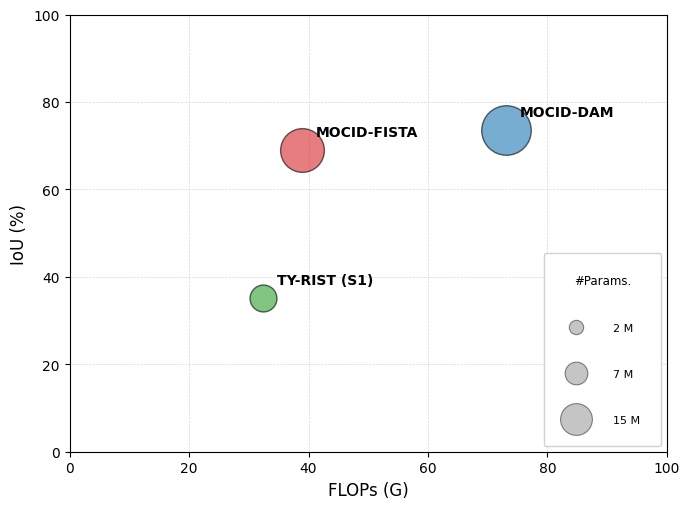

wrote results/sota_daub/iou_vs_flops.png


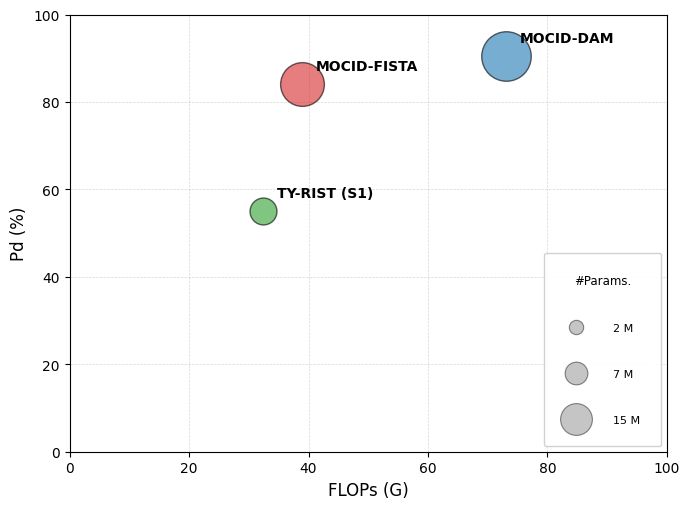

wrote results/sota_daub/pd_vs_flops.png


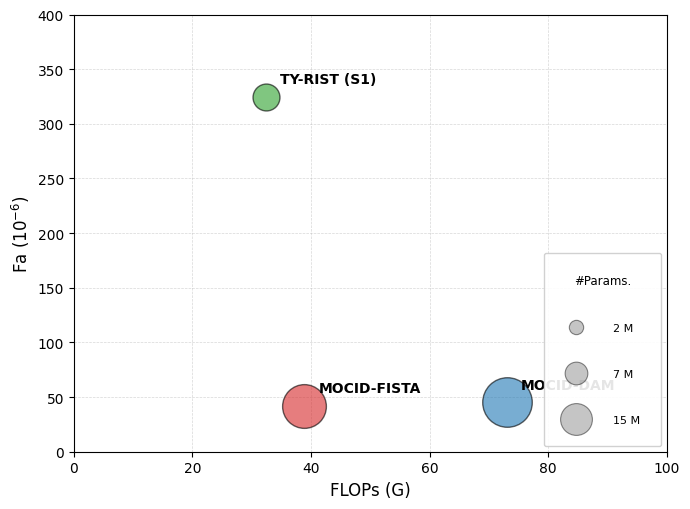

wrote results/sota_daub/fa_vs_flops.png


In [28]:
results = mocid_results + tyrist_results

specs = [
    ("iou", "IoU (%)", "iou_vs_flops.png"),
    ("pd", "Pd (%)", "pd_vs_flops.png"),
    ("fa", "Fa ($10^{-6}$)", "fa_vs_flops.png"),
]
for key, ylabel, fname in specs:
    out = plot_bubble(results, key, ylabel, EVAL_DIR / fname)
    print("wrote", out)